# Anime Character Storyboard
A procedurally generated 4-scene storyboard featuring a persistent anime-style character.
Rendered entirely with matplotlib — no generative AI, no external assets.

In [1]:
# ─────────────────────────────────────────────
# Cell 1: Imports
# ─────────────────────────────────────────────
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, Arc, Wedge, Circle, Ellipse, FancyBboxPatch
from matplotlib.transforms import Affine2D
from matplotlib.path import Path
import matplotlib.patheffects as pe
import warnings
warnings.filterwarnings('ignore')

# Fix random seed for full determinism
np.random.seed(42)

print('Imports OK')

Imports OK


In [2]:
# ─────────────────────────────────────────────
# Cell 2: Colour Palette
# ─────────────────────────────────────────────
PALETTE = dict(
    skin        = '#F4C2A1',
    skin_shadow = '#E0A882',
    hair        = '#6B3A2A',
    hair_shine  = '#8B5A3A',
    eye         = '#3A2A1A',
    eye_white   = '#FFFFFF',
    mouth       = '#C07070',
    tshirt      = '#A8D8EA',     # light blue
    raincoat    = '#F6C90E',     # yellow
    raincoat_d  = '#D4A800',     # darker yellow (lapel/shadow)
    shorts      = '#3A5A7C',     # dark denim
    shorts_hi   = '#4A6A8C',
    sock        = '#BEBEBE',     # gray
    boot        = '#4A7AB5',     # blue
    boot_shine  = '#6A9AD5',
    outline     = '#1A1A2E',
)

print('Palette defined')

Palette defined


In [3]:
# ─────────────────────────────────────────────
# Cell 3: Drawing Helpers
# ─────────────────────────────────────────────

def rotated_ellipse(ax, cx, cy, w, h, angle_deg, color, zorder=5, lw=1.2, ec=None):
    """Draw a filled, rotated ellipse."""
    if ec is None:
        ec = PALETTE['outline']
    e = Ellipse((cx, cy), w, h, angle=angle_deg,
                fc=color, ec=ec, lw=lw, zorder=zorder)
    ax.add_patch(e)
    return e


def rotated_rect(ax, cx, cy, w, h, angle_deg, color, zorder=5, lw=1.2, ec=None):
    """Draw a filled rectangle centred at (cx,cy) with rotation."""
    if ec is None:
        ec = PALETTE['outline']
    rect = FancyBboxPatch((-w/2, -h/2), w, h,
                          boxstyle='round,pad=0.01',
                          fc=color, ec=ec, lw=lw, zorder=zorder)
    tr = Affine2D().rotate_deg(angle_deg).translate(cx, cy)
    rect.set_transform(tr + ax.transData)
    ax.add_patch(rect)
    return rect


def filled_polygon(ax, pts, color, zorder=5, lw=1.2, ec=None):
    """Draw a filled polygon from a list of (x,y) points."""
    if ec is None:
        ec = PALETTE['outline']
    poly = plt.Polygon(pts, closed=True, fc=color, ec=ec, lw=lw, zorder=zorder)
    ax.add_patch(poly)
    return poly


def rotate_pt(x, y, cx, cy, deg):
    """Rotate point (x,y) around centre (cx,cy) by deg degrees."""
    r = np.deg2rad(deg)
    dx, dy = x - cx, y - cy
    nx = cx + dx * np.cos(r) - dy * np.sin(r)
    ny = cy + dx * np.sin(r) + dy * np.cos(r)
    return nx, ny


def rotate_pts(pts, cx, cy, deg):
    return [rotate_pt(x, y, cx, cy, deg) for x, y in pts]


print('Helpers defined')

Helpers defined


In [4]:
# ─────────────────────────────────────────────
# Cell 4: Character Class
# ─────────────────────────────────────────────

class AnimeCharacter:
    """
    Persistent anime-style 8-year-old girl with:
      - Short brown bob haircut
      - Yellow raincoat (open)
      - Light blue t-shirt
      - Dark denim shorts (mid-thigh)
      - Bare legs
      - Gray ankle socks
      - Blue mid-calf rain boots

    Pose is controlled via the `pose` dict passed to draw().
    """

    # ── Proportions (all relative to body_height=1.0) ──────────────────────
    BODY_H      = 1.0      # torso reference
    HEAD_R      = 0.38     # head radius (children: big head)
    TORSO_W     = 0.40
    TORSO_H     = 0.55
    UPPER_ARM_L = 0.30
    UPPER_ARM_W = 0.10
    LOWER_ARM_L = 0.28
    LOWER_ARM_W = 0.09
    UPPER_LEG_L = 0.42
    UPPER_LEG_W = 0.14
    LOWER_LEG_L = 0.36
    LOWER_LEG_W = 0.12
    SOCK_H      = 0.08
    BOOT_H      = 0.20

    def __init__(self, name='Yuki'):
        self.name = name

    # ── Default pose ────────────────────────────────────────────────────────
    def _default_pose(self):
        return dict(
            facing        = 'front',   # 'front' | 'back' | 'side_right' | 'side_left'
            torso_tilt    = 0,         # degrees CW
            head_tilt     = 0,
            l_upper_arm   = -10,       # angle from vertical (+ = forward)
            l_lower_arm   = 0,
            r_upper_arm   = 10,
            r_lower_arm   = 0,
            l_upper_leg   = 0,
            l_lower_leg   = 0,
            r_upper_leg   = 0,
            r_lower_leg   = 0,
            crouch        = 0.0,       # 0–1, compress vertical positions
            flip_x        = False,     # mirror the whole drawing
        )

    # ── Master draw method ─────────────────────────────────────────────────
    def draw(self, ax, cx=0.0, cy=0.0, scale=1.0, pose=None):
        """
        Render the character centred at (cx, cy) with the given scale.
        `pose` is a dict overriding any default pose values.
        """
        p = self._default_pose()
        if pose:
            p.update(pose)

        # Scale all proportions
        s = scale
        H  = self.BODY_H * s
        HR = self.HEAD_R * s

        # Crouch offset compresses the figure vertically
        cr = p['crouch']

        # ── Skeleton anchor points (relative to cy, bottom of feet) ────────
        # We build from bottom up.
        boot_h    = self.BOOT_H  * s
        sock_h    = self.SOCK_H  * s
        uleg_l    = self.UPPER_LEG_L * s * (1 - 0.3*cr)
        lleg_l    = self.LOWER_LEG_L * s * (1 - 0.3*cr)
        torso_h   = self.TORSO_H * s * (1 - 0.2*cr)

        feet_y    = cy
        ankle_y   = feet_y + boot_h
        knee_y    = ankle_y + lleg_l
        hip_y     = knee_y + uleg_l
        shoulder_y= hip_y + torso_h
        neck_y    = shoulder_y - 0.04*s
        head_cy   = neck_y + HR * 0.85

        # horizontal offsets for legs
        hip_half  = self.TORSO_W * s * 0.30
        lhip_x    = cx - hip_half
        rhip_x    = cx + hip_half

        facing = p['facing']
        side   = facing in ('side_right', 'side_left')
        back   = facing == 'back'

        # ── Draw order: back-limbs, torso, front-limbs, head ────────────────
        self._draw_legs(ax, cx, cy, p, s, lhip_x, rhip_x,
                        hip_y, knee_y, ankle_y, feet_y, side, back)
        self._draw_torso(ax, cx, hip_y, shoulder_y, s, p, side, back)
        self._draw_arms(ax, cx, shoulder_y, s, p, side, back)
        self._draw_head(ax, cx, head_cy, HR, s, p, back)

        # Mirror if needed
        if p['flip_x']:
            # Already drawn; we'll handle via ax transform at call site
            pass

    # ── Head ────────────────────────────────────────────────────────────────
    def _draw_head(self, ax, cx, cy, HR, s, p, back):
        facing = p['facing']
        side   = facing in ('side_right', 'side_left')

        # Head circle
        rotated_ellipse(ax, cx, cy, HR*2.1, HR*2, p['head_tilt'],
                        PALETTE['skin'], zorder=20)

        # ── Hair bob ────────────────────────────────────────────────────────
        hc = PALETTE['hair']
        hs = PALETTE['hair_shine']

        if not side:
            # Top hair dome
            rotated_ellipse(ax, cx, cy + HR*0.15, HR*2.0, HR*1.55, 0,
                            hc, zorder=21)
            # Side flaps
            rotated_ellipse(ax, cx - HR*0.82, cy - HR*0.10, HR*0.75, HR*1.3, -12,
                            hc, zorder=19, ec=hc)
            rotated_ellipse(ax, cx + HR*0.82, cy - HR*0.10, HR*0.75, HR*1.3,  12,
                            hc, zorder=19, ec=hc)
            # Fringe
            fringe_pts = [
                (cx - HR*0.85, cy + HR*0.45),
                (cx - HR*0.55, cy + HR*0.15),
                (cx - HR*0.25, cy + HR*0.30),
                (cx,           cy + HR*0.18),
                (cx + HR*0.25, cy + HR*0.30),
                (cx + HR*0.55, cy + HR*0.15),
                (cx + HR*0.85, cy + HR*0.45),
            ]
            filled_polygon(ax, fringe_pts + [(cx+HR, cy+HR*0.9),(cx-HR, cy+HR*0.9)],
                           hc, zorder=22, ec=hc)
        else:
            # Side profile hair
            sign = 1 if facing == 'side_right' else -1
            rotated_ellipse(ax, cx + sign*HR*0.05, cy + HR*0.18, HR*1.95, HR*1.6, 0,
                            hc, zorder=21)
            # Back hair drop
            rotated_ellipse(ax, cx - sign*HR*0.35, cy - HR*0.20, HR*0.55, HR*1.1, 0,
                            hc, zorder=19, ec=hc)

        # Hair highlight
        rotated_ellipse(ax, cx + HR*0.15, cy + HR*0.55, HR*0.4, HR*0.18, -20,
                        hs, zorder=23, lw=0, ec=hs)

        if not back:
            if not side:
                # Eyes
                for ex in [cx - HR*0.32, cx + HR*0.32]:
                    rotated_ellipse(ax, ex, cy, HR*0.22, HR*0.26, 0,
                                    PALETTE['eye_white'], zorder=24, lw=0.8)
                    rotated_ellipse(ax, ex + HR*0.02, cy - HR*0.03, HR*0.14, HR*0.18, 0,
                                    PALETTE['eye'], zorder=25, lw=0)
                    # Catchlight
                    rotated_ellipse(ax, ex + HR*0.05, cy + HR*0.05, HR*0.05, HR*0.05, 0,
                                    'white', zorder=26, lw=0)
                # Mouth
                arc = Arc((cx, cy - HR*0.30), HR*0.25, HR*0.14,
                          angle=0, theta1=200, theta2=340,
                          color=PALETTE['mouth'], lw=1.5, zorder=25)
                ax.add_patch(arc)
                # Nose
                rotated_ellipse(ax, cx, cy - HR*0.12, HR*0.06, HR*0.04, 0,
                                PALETTE['skin_shadow'], zorder=24, lw=0, ec=PALETTE['skin_shadow'])
            else:
                # Side face features
                sign = 1 if facing == 'side_right' else -1
                ex = cx + sign*HR*0.30
                rotated_ellipse(ax, ex, cy + HR*0.02, HR*0.16, HR*0.22, 0,
                                PALETTE['eye'], zorder=25, lw=0)
                rotated_ellipse(ax, ex + sign*HR*0.04, cy + HR*0.08, HR*0.05, HR*0.05, 0,
                                'white', zorder=26, lw=0)
                # Nose bump
                rotated_ellipse(ax, cx + sign*HR*0.82, cy - HR*0.12, HR*0.10, HR*0.07, 0,
                                PALETTE['skin_shadow'], zorder=24, lw=0, ec=PALETTE['skin_shadow'])

    # ── Torso ───────────────────────────────────────────────────────────────
    def _draw_torso(self, ax, cx, hip_y, shoulder_y, s, p, side, back):
        TW = self.TORSO_W * s
        TH = shoulder_y - hip_y
        cy_t = (hip_y + shoulder_y) / 2

        # Shorts (upper part, waistband)
        sh = self.UPPER_LEG_L * s * 0.55
        SW = TW * (0.55 if side else 1.05)
        rotated_rect(ax, cx, hip_y + sh*0.45, SW, sh*1.1, 0,
                     PALETTE['shorts'], zorder=9)
        # Shorts highlight
        rotated_rect(ax, cx - TW*0.1, hip_y + sh*0.55, SW*0.35, sh*0.5, 0,
                     PALETTE['shorts_hi'], zorder=10, lw=0, ec=PALETTE['shorts_hi'])

        # T-shirt
        if side:
            rotated_rect(ax, cx, cy_t, TW*0.55, TH*0.98, 0,
                         PALETTE['tshirt'], zorder=10)
        else:
            rotated_rect(ax, cx, cy_t, TW*1.05, TH*0.98, 0,
                         PALETTE['tshirt'], zorder=10)

        # Raincoat panels (open coat — two lapels)
        rc = PALETTE['raincoat']
        rcd = PALETTE['raincoat_d']

        if not side:
            # Left panel
            lp = [
                (cx - TW*0.05, shoulder_y),
                (cx - TW*0.60, shoulder_y - TH*0.07),
                (cx - TW*0.65, hip_y + TH*0.05),
                (cx - TW*0.08, hip_y - TH*0.02),
            ]
            filled_polygon(ax, lp, rc, zorder=11)
            # Right panel
            rp = [
                (cx + TW*0.05, shoulder_y),
                (cx + TW*0.60, shoulder_y - TH*0.07),
                (cx + TW*0.65, hip_y + TH*0.05),
                (cx + TW*0.08, hip_y - TH*0.02),
            ]
            filled_polygon(ax, rp, rc, zorder=11)
            # Collar lapels
            for sign in [-1, 1]:
                cl = [
                    (cx + sign*TW*0.04, shoulder_y),
                    (cx + sign*TW*0.55, shoulder_y - TH*0.02),
                    (cx + sign*TW*0.45, shoulder_y - TH*0.18),
                    (cx + sign*TW*0.04, shoulder_y - TH*0.22),
                ]
                filled_polygon(ax, cl, rcd, zorder=12)
        else:
            # Side: one visible panel
            sp = [
                (cx - TW*0.28, shoulder_y + TH*0.04),
                (cx + TW*0.38, shoulder_y),
                (cx + TW*0.40, hip_y + TH*0.05),
                (cx - TW*0.25, hip_y - TH*0.02),
            ]
            filled_polygon(ax, sp, rc, zorder=11)

    # ── Arms ────────────────────────────────────────────────────────────────
    def _draw_arms(self, ax, cx, shoulder_y, s, p, side, back):
        TW   = self.TORSO_W * s
        UAL  = self.UPPER_ARM_L * s
        UAW  = self.UPPER_ARM_W * s
        LAL  = self.LOWER_ARM_L * s
        LAW  = self.LOWER_ARM_W * s

        if side:
            # In side view we just draw one arm (front)
            ua_ang = p['r_upper_arm'] if p['facing'] == 'side_right' else p['l_upper_arm']
            la_ang = p['r_lower_arm'] if p['facing'] == 'side_right' else p['l_lower_arm']
            self._limb(ax,
                       cx, shoulder_y - UAW*0.3,
                       UAL, UAW, ua_ang,
                       PALETTE['raincoat'], zorder=13)
            elbow_x = cx + UAL * np.sin(np.deg2rad(ua_ang))
            elbow_y = shoulder_y - UAW*0.3 - UAL * np.cos(np.deg2rad(ua_ang))
            self._limb(ax, elbow_x, elbow_y,
                       LAL, LAW, ua_ang + la_ang,
                       PALETTE['skin'], zorder=14)
            return

        for side_sign, ua_key, la_key, zo in [
                (-1, 'l_upper_arm', 'l_lower_arm', 8),
                ( 1, 'r_upper_arm', 'r_lower_arm', 15)]:
            sx = cx + side_sign * TW * 0.52
            sy = shoulder_y - UAW * 0.3
            ua_ang = p[ua_key]
            la_ang = p[la_key]
            # Coat sleeve
            self._limb(ax, sx, sy, UAL, UAW * 1.3, ua_ang,
                       PALETTE['raincoat'], zorder=zo)
            elbow_x = sx + UAL * np.sin(np.deg2rad(ua_ang))
            elbow_y = sy - UAL * np.cos(np.deg2rad(ua_ang))
            # Forearm (skin visible below sleeve)
            self._limb(ax, elbow_x, elbow_y, LAL, LAW, ua_ang + la_ang,
                       PALETTE['skin'], zorder=zo+1)

    # ── Legs ────────────────────────────────────────────────────────────────
    def _draw_legs(self, ax, cx, cy, p, s,
                   lhip_x, rhip_x, hip_y, knee_y, ankle_y, feet_y, side, back):
        ULW = self.UPPER_LEG_W * s
        LLW = self.LOWER_LEG_W * s
        ULL = self.UPPER_LEG_L * s * (1 - 0.3*p['crouch'])
        LLL = self.LOWER_LEG_L * s * (1 - 0.3*p['crouch'])
        SOCKH = self.SOCK_H * s
        BOOTH = self.BOOT_H * s

        def one_leg(hx, hy, ua, la, zo_back, zo_front, side_mode=False):
            # Upper leg (bare skin)
            kx = hx + ULL * np.sin(np.deg2rad(ua))
            ky = hy - ULL * np.cos(np.deg2rad(ua))
            self._limb(ax, hx, hy, ULL, ULW, ua, PALETTE['skin'], zorder=zo_back)
            # Lower leg (bare skin)
            ax2 = kx + LLL * np.sin(np.deg2rad(ua + la))
            ay2 = ky - LLL * np.cos(np.deg2rad(ua + la))
            self._limb(ax, kx, ky, LLL, LLW, ua+la, PALETTE['skin'], zorder=zo_front)
            # Sock
            self._limb(ax, ax2 - SOCKH*np.sin(np.deg2rad(ua+la)),
                       ay2 + SOCKH*np.cos(np.deg2rad(ua+la)),
                       SOCKH*1.5, LLW*0.9, ua+la, PALETTE['sock'], zorder=zo_front+1)
            # Boot
            bx = ax2
            by = ay2
            self._limb(ax, bx, by, BOOTH, LLW*1.15, ua+la, PALETTE['boot'], zorder=zo_front+2)
            # Boot shine
            self._limb(ax,
                       bx + 0.06*s*np.cos(np.deg2rad(ua+la)),
                       by + 0.06*s*np.sin(np.deg2rad(ua+la)),
                       BOOTH*0.55, LLW*0.28, ua+la,
                       PALETTE['boot_shine'], zorder=zo_front+3, lw=0)

        if side:
            sign = 1 if p['facing'] == 'side_right' else -1
            one_leg(cx, hip_y, p['l_upper_leg'], p['l_lower_leg'], 7, 8)
            one_leg(cx, hip_y, p['r_upper_leg'], p['r_lower_leg'], 5, 6)
        else:
            one_leg(lhip_x, hip_y, p['l_upper_leg'], p['l_lower_leg'], 5, 6)
            one_leg(rhip_x, hip_y, p['r_upper_leg'], p['r_lower_leg'], 7, 8)

    # ── Generic limb segment (elongated ellipse) ────────────────────────────
    def _limb(self, ax, sx, sy, length, width, angle_deg, color, zorder=5, lw=1.2):
        """
        Draw a limb segment starting at (sx,sy), extending downward by `length`
        with the given rotation.
        """
        r = np.deg2rad(angle_deg)
        ex = sx + length * np.sin(r)
        ey = sy - length * np.cos(r)
        # Centre of the limb
        mx = (sx + ex) / 2
        my = (sy + ey) / 2
        rotated_ellipse(ax, mx, my, width, length, -angle_deg,
                        color, zorder=zorder, lw=lw)


print('AnimeCharacter class defined')

AnimeCharacter class defined


In [5]:
# ─────────────────────────────────────────────
# Cell 5: Background helpers
# ─────────────────────────────────────────────

def draw_sky(ax, xlim, ylim, top_color='#87CEEB', bottom_color='#D0EEFF'):
    """Sky gradient via stacked horizontal strips."""
    steps = 30
    tc = np.array(matplotlib.colors.to_rgb(top_color))
    bc = np.array(matplotlib.colors.to_rgb(bottom_color))
    ys = np.linspace(ylim[0], ylim[1], steps+1)
    for i in range(steps):
        t  = i / steps
        c  = tuple(tc * (1-t) + bc * t)
        ax.fill_between(xlim, ys[i], ys[i+1], color=c, lw=0)


def draw_ground(ax, xlim, ground_y, grass_color='#5DBB63', soil_color='#8B6914'):
    """Simple flat ground strip."""
    ax.fill_between(xlim, ground_y - 0.8, ground_y, color=soil_color, lw=0)
    ax.fill_between(xlim, ground_y, ground_y + 0.12, color=grass_color, lw=0)


def draw_grass_tufts(ax, xlim, ground_y, n=35, rng=None):
    """Scatter small grass triangles along the ground."""
    if rng is None:
        rng = np.random.default_rng(0)
    xs = rng.uniform(xlim[0], xlim[1], n)
    for x in xs:
        h  = rng.uniform(0.05, 0.18)
        w  = rng.uniform(0.04, 0.09)
        pts = [(x - w, ground_y), (x, ground_y + h), (x + w, ground_y)]
        g = rng.uniform(0.3, 0.65)
        ax.add_patch(plt.Polygon(pts, closed=True,
                                  fc=(0.15+g*0.25, 0.45+g*0.3, 0.15+g*0.15), ec='none'))


def draw_clouds(ax, xlim, ylim, n=4, rng=None):
    """Simple puffy clouds."""
    if rng is None:
        rng = np.random.default_rng(1)
    for _ in range(n):
        x = rng.uniform(xlim[0]+0.5, xlim[1]-0.5)
        y = rng.uniform(ylim[1]*0.60, ylim[1]*0.92)
        for dx, dy, r in [(0,0,0.28),(0.25,0.07,0.22),(-0.22,0.05,0.20),(0.10,-0.10,0.18)]:
            ax.add_patch(Circle((x+dx, y+dy), r, fc='white', ec='none', alpha=0.88, zorder=2))


def draw_flower(ax, x, y, s=0.08, color='#FF6B9D', rng=None):
    """Simple 5-petal daisy."""
    if rng is None:
        rng = np.random.default_rng(5)
    for i in range(5):
        a = np.deg2rad(i * 72)
        px = x + s * 1.4 * np.cos(a)
        py = y + s * 1.4 * np.sin(a)
        ax.add_patch(Ellipse((px, py), s*1.1, s*0.6, angle=np.rad2deg(a),
                             fc=color, ec='none', zorder=3))
    ax.add_patch(Circle((x, y), s*0.55, fc='#FFD700', ec='none', zorder=4))
    # Stem
    ax.plot([x, x], [y - s*0.5, y - s*2.2], color='#3A7D3A', lw=1.5, zorder=2)


def base_scene(figsize=(6,5), xlim=(0,6), ylim=(0,5), ground_y=1.5):
    """Create a figure with sky + ground + clouds + grass."""
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect('equal')
    ax.axis('off')

    rng = np.random.default_rng(99)   # deterministic
    draw_sky(ax, xlim, ylim)
    draw_clouds(ax, xlim, ylim, rng=rng)
    draw_ground(ax, xlim, ground_y)
    draw_grass_tufts(ax, xlim, ground_y, rng=rng)
    return fig, ax


print('Background helpers defined')

Background helpers defined


In [6]:
# ─────────────────────────────────────────────
# Cell 6: Create the single persistent character object
# ─────────────────────────────────────────────

yuki = AnimeCharacter(name='Yuki')
print(f'Character "{yuki.name}" ready — reused in all 4 scenes.')

Character "Yuki" ready — reused in all 4 scenes.


FileNotFoundError: [Errno 2] No such file or directory: '/tmp/scene1.png'

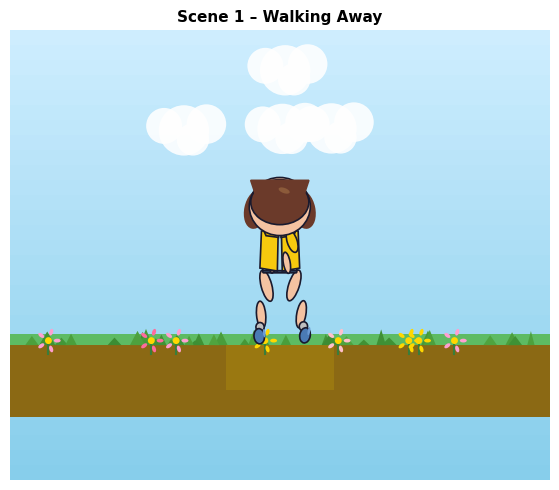

In [7]:
# ─────────────────────────────────────────────
# Cell 7: Scene 1 — Walking away in a field
#          Facing back, mid-stride
# ─────────────────────────────────────────────

scene_images = []   # we will collect rendered arrays here

GY = 1.5   # ground_y shared across scenes
SCALE = 0.85

fig1, ax1 = base_scene()
ax1.set_title('Scene 1 – Walking Away', fontsize=11, pad=6, fontweight='bold')

# Scatter flowers in background
rng_f = np.random.default_rng(7)
for _ in range(8):
    fx = rng_f.uniform(0.4, 5.6)
    fc = rng_f.choice(['#FF6B9D','#FF9FD0','#FFC0CB','#FFD700'])
    draw_flower(ax1, fx, GY + 0.05, s=0.07, color=fc, rng=rng_f)

walk_away_pose = dict(
    facing       = 'back',
    l_upper_leg  = -15,
    l_lower_leg  = 10,
    r_upper_leg  =  18,
    r_lower_leg  = -8,
    l_upper_arm  =  20,
    l_lower_arm  = -10,
    r_upper_arm  = -18,
    r_lower_arm  =  8,
)

yuki.draw(ax1, cx=3.0, cy=GY, scale=SCALE, pose=walk_away_pose)

# Path / trail
ax1.fill_between([2.4, 3.6], GY - 0.5, GY, color='#B8960C', alpha=0.35, lw=0, zorder=1)

plt.tight_layout()
plt.savefig('/tmp/scene1.png', dpi=120, bbox_inches='tight')
plt.show()

# Capture for storyboard
from matplotlib.backends.backend_agg import FigureCanvasAgg
canvas1 = FigureCanvasAgg(fig1)
canvas1.draw()
w1, h1 = canvas1.get_width_height()
buf1 = np.frombuffer(canvas1.buffer_rgba(), dtype=np.uint8).reshape(h1, w1, 4)[:, :, :3]
scene_images.append(buf1)
plt.close(fig1)
print('Scene 1 rendered')

In [ ]:
# ─────────────────────────────────────────────
# Cell 8: Scene 2 — Kneeling to examine a flower
#          Front-facing, crouched
# ─────────────────────────────────────────────

fig2, ax2 = base_scene()
ax2.set_title('Scene 2 – Kneeling at a Flower', fontsize=11, pad=6, fontweight='bold')

# A single prominent flower
draw_flower(ax2, 3.55, GY + 0.06, s=0.13, color='#FF6B9D')
# Background flowers
rng_f2 = np.random.default_rng(11)
for _ in range(6):
    draw_flower(ax2, rng_f2.uniform(0.5,5.5), GY+0.04,
                s=0.06, color=rng_f2.choice(['#FF9FD0','#FFD700','#A8E6CF']))

kneel_pose = dict(
    facing       = 'front',
    head_tilt    = 18,       # looking down
    crouch       = 0.65,
    l_upper_leg  =  25,
    l_lower_leg  = -85,
    r_upper_leg  = -20,
    r_lower_leg  =  80,
    l_upper_arm  =  45,
    l_lower_arm  = -55,
    r_upper_arm  =  30,
    r_lower_arm  = -40,
)

yuki.draw(ax2, cx=3.0, cy=GY, scale=SCALE, pose=kneel_pose)

plt.tight_layout()
plt.savefig('/tmp/scene2.png', dpi=120, bbox_inches='tight')
plt.show()

canvas2 = FigureCanvasAgg(fig2)
canvas2.draw()
w2, h2 = canvas2.get_width_height()
buf2 = np.frombuffer(canvas2.buffer_rgba(), dtype=np.uint8).reshape(h2, w2, 4)[:, :, :3]
scene_images.append(buf2)
plt.close(fig2)
print('Scene 2 rendered')

In [ ]:
# ─────────────────────────────────────────────
# Cell 9: Scene 3 — Standing, looking down at a flower
#          Front-facing, upright, head tilted
# ─────────────────────────────────────────────

fig3, ax3 = base_scene()
ax3.set_title('Scene 3 – Standing, Looking Down', fontsize=11, pad=6, fontweight='bold')

# Flower right beside her
draw_flower(ax3, 3.65, GY + 0.06, s=0.14, color='#FFD700')
rng_f3 = np.random.default_rng(13)
for _ in range(5):
    draw_flower(ax3, rng_f3.uniform(0.3,5.7), GY+0.04,
                s=0.06, color=rng_f3.choice(['#FF6B9D','#A8E6CF','#B39DDB']))

stand_look_pose = dict(
    facing       = 'front',
    head_tilt    = 22,
    l_upper_arm  = -8,
    r_upper_arm  =  8,
    l_upper_leg  =  4,
    r_upper_leg  = -4,
)

yuki.draw(ax3, cx=3.0, cy=GY, scale=SCALE, pose=stand_look_pose)

plt.tight_layout()
plt.savefig('/tmp/scene3.png', dpi=120, bbox_inches='tight')
plt.show()

canvas3 = FigureCanvasAgg(fig3)
canvas3.draw()
w3, h3 = canvas3.get_width_height()
buf3 = np.frombuffer(canvas3.buffer_rgba(), dtype=np.uint8).reshape(h3, w3, 4)[:, :, :3]
scene_images.append(buf3)
plt.close(fig3)
print('Scene 3 rendered')

In [ ]:
# ─────────────────────────────────────────────
# Cell 10: Scene 4 — Side silhouette walking
#           Side-right view, brisk stride
# ─────────────────────────────────────────────

fig4, ax4 = base_scene()
ax4.set_title('Scene 4 – Side Silhouette Walking', fontsize=11, pad=6, fontweight='bold')

rng_f4 = np.random.default_rng(17)
for _ in range(7):
    draw_flower(ax4, rng_f4.uniform(0.3,5.7), GY+0.04,
                s=0.07, color=rng_f4.choice(['#FF6B9D','#FFD700','#A8E6CF']))

side_walk_pose = dict(
    facing       = 'side_right',
    l_upper_leg  =  22,
    l_lower_leg  = -15,
    r_upper_leg  = -20,
    r_lower_leg  =  12,
    r_upper_arm  = -25,
    r_lower_arm  =  15,
)

yuki.draw(ax4, cx=3.0, cy=GY, scale=SCALE, pose=side_walk_pose)

# Motion lines for flair
for ly in [GY+0.6, GY+0.9, GY+1.2]:
    ax4.plot([1.5, 2.2], [ly, ly], color='#AAAACC', lw=0.8, alpha=0.5, zorder=1)

plt.tight_layout()
plt.savefig('/tmp/scene4.png', dpi=120, bbox_inches='tight')
plt.show()

canvas4 = FigureCanvasAgg(fig4)
canvas4.draw()
w4, h4 = canvas4.get_width_height()
buf4 = np.frombuffer(canvas4.buffer_rgba(), dtype=np.uint8).reshape(h4, w4, 4)[:, :, :3]
scene_images.append(buf4)
plt.close(fig4)
print('Scene 4 rendered')

In [ ]:
# ─────────────────────────────────────────────
# Cell 11: Combine into 2×2 storyboard
# ─────────────────────────────────────────────

from PIL import Image as PILImage
import io

TARGET = (600, 500)   # each panel target size

def arr_to_pil(arr):
    return PILImage.fromarray(arr.astype(np.uint8))

panels = [arr_to_pil(im).resize(TARGET, PILImage.LANCZOS) for im in scene_images]

# Board = 2 cols × 2 rows with thin border
BORDER = 6
BG_COLOR = (30, 30, 50)   # dark blue-grey background

board_w = TARGET[0]*2 + BORDER*3
board_h = TARGET[1]*2 + BORDER*3 + 50   # +50 for title bar

board = PILImage.new('RGB', (board_w, board_h), BG_COLOR)

for idx, panel in enumerate(panels):
    row = idx // 2
    col = idx % 2
    x = BORDER + col * (TARGET[0] + BORDER)
    y = 50 + BORDER + row * (TARGET[1] + BORDER)
    board.paste(panel, (x, y))

# Add title text via matplotlib (avoid PIL font dependency)
fig_board, ax_board = plt.subplots(figsize=(board_w/100, board_h/100), dpi=100)
ax_board.imshow(np.array(board))
ax_board.text(board_w/2, 26, '✨ Yuki in the Field — Storyboard',
              ha='center', va='center', fontsize=14, fontweight='bold',
              color='white',
              path_effects=[pe.withStroke(linewidth=2, foreground='black')])
ax_board.axis('off')
plt.tight_layout(pad=0)
plt.savefig('/tmp/storyboard.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close(fig_board)

print('2×2 storyboard saved to /tmp/storyboard.png')